In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42) 

### Task 1 — Convolution Mechanics: Filters and Shapes

Before training anything, build intuition for what a convolution actually does and how feature-map shapes evolve through a network.

**Part A — Handcrafted filters.**

1. Load a single CIFAR-10 image and convert it to a `torch.Tensor` of shape `(1, 3, 32, 32)`.
2. Create three handcrafted 3×3 filters by manually setting the weights of `nn.Conv2d(3, 1, kernel_size=3, padding=1)`:
   - **Vertical edge detector**: `[[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]]`
   - **Horizontal edge detector**: transpose of the above
   - **Blur**: `(1/9) * np.ones((3, 3))`
3. Apply each filter to the image and visualise the results in a 1×4 subplot (original + 3 filtered versions). Use `imshow(..., cmap="gray")` for the filtered outputs.
4. In a markdown cell, briefly describe what each filter highlights. 

In [3]:
transform = transforms.ToTensor()

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

image, label = dataset[0]

image = image.unsqueeze(0).to(device) 

100%|██████████| 170M/170M [01:15<00:00, 2.26MB/s] 


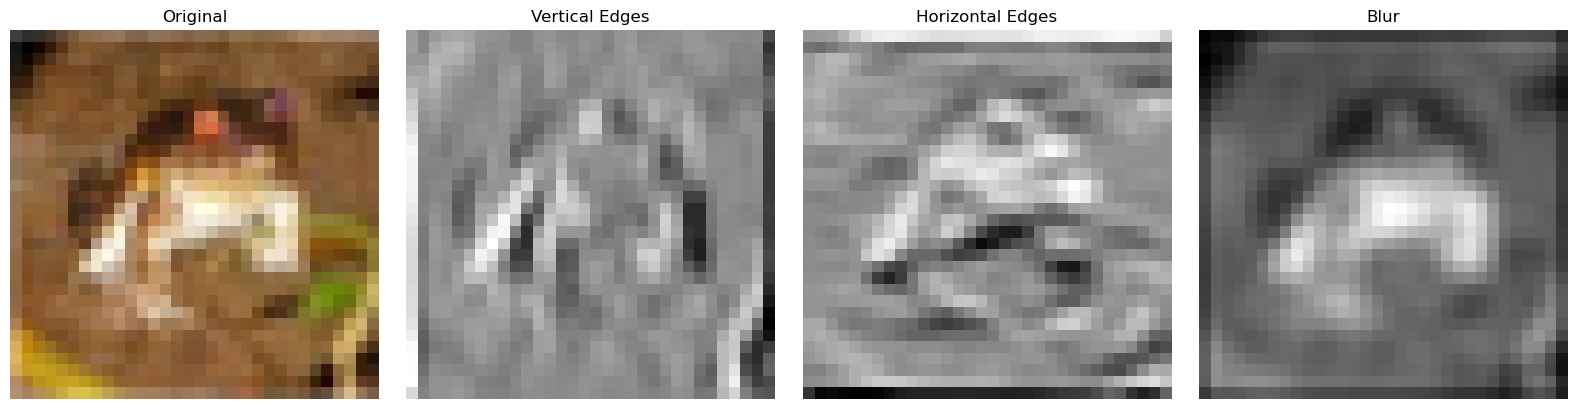

In [5]:
vertical_kernel = torch.tensor([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=torch.float32)

horizontal_kernel = vertical_kernel.T

blur_kernel = (1/9) * torch.ones((3, 3), dtype=torch.float32)


def apply_filter(kernel):

    conv = nn.Conv2d(
        in_channels=3,
        out_channels=1,
        kernel_size=3,
        padding=1,
        bias=False
    ).to(device)

    kernel = kernel.unsqueeze(0).unsqueeze(0)
    kernel = kernel.repeat(1, 3, 1, 1)

    with torch.no_grad():
        conv.weight.copy_(kernel)

    output = conv(image)

    return output.squeeze().detach().cpu().numpy()

vertical_output = apply_filter(vertical_kernel)
horizontal_output = apply_filter(horizontal_kernel)
blur_output = apply_filter(blur_kernel)


original = image.squeeze().permute(1, 2, 0).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(vertical_output, cmap="gray")
axes[1].set_title("Vertical Edges")
axes[1].axis("off")

axes[2].imshow(horizontal_output, cmap="gray")
axes[2].set_title("Horizontal Edges")
axes[2].axis("off")

axes[3].imshow(blur_output, cmap="gray")
axes[3].set_title("Blur")
axes[3].axis("off")

plt.tight_layout()
plt.show()

### Filter Observations

- The vertical edge detector highlights vertical structures and boundaries in the image.
- The horizontal edge detector highlights horizontal lines and edges.
- The blur filter smooths the image by averaging nearby pixel values, reducing sharp details and noise.

### Task 2 — Train a Small CNN on CIFAR-10

Build a complete CNN classifier and train it.

1. Define a CNN with this architecture:
   - Block 1: `Conv2d(3, 32, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(32, 32, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Block 2: `Conv2d(32, 64, k=3, p=1)` → BatchNorm → ReLU → `Conv2d(64, 64, k=3, p=1)` → BatchNorm → ReLU → `MaxPool2d(2)`
   - Classifier: `Flatten` → `Linear(64*8*8, 256)` → ReLU → `Dropout(0.3)` → `Linear(256, 10)`
2. Compute the parameter count of your model and report it.
3. Train for **15 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Use batch size 128.
4. Track training and validation loss + accuracy per epoch. Plot the curves.

**Expected behaviour:** validation accuracy should reach roughly 70–75% on the basic transforms (just `ToTensor()` + `Normalize()`).

Total Parameters: 1117354
Epoch 1/15
Train Loss: 1.4225 | Train Acc: 0.4838
Val Loss:   1.1035 | Val Acc:   0.6046
--------------------------------------------------
Epoch 2/15
Train Loss: 0.9943 | Train Acc: 0.6464
Val Loss:   0.9010 | Val Acc:   0.6770
--------------------------------------------------
Epoch 3/15
Train Loss: 0.8405 | Train Acc: 0.7048
Val Loss:   0.8183 | Val Acc:   0.7032
--------------------------------------------------
Epoch 4/15
Train Loss: 0.7498 | Train Acc: 0.7369
Val Loss:   0.7200 | Val Acc:   0.7384
--------------------------------------------------
Epoch 5/15
Train Loss: 0.6848 | Train Acc: 0.7582
Val Loss:   0.7761 | Val Acc:   0.7284
--------------------------------------------------
Epoch 6/15
Train Loss: 0.6327 | Train Acc: 0.7779
Val Loss:   0.6948 | Val Acc:   0.7430
--------------------------------------------------
Epoch 7/15
Train Loss: 0.5748 | Train Acc: 0.7965
Val Loss:   0.6418 | Val Acc:   0.7698
---------------------------------------------

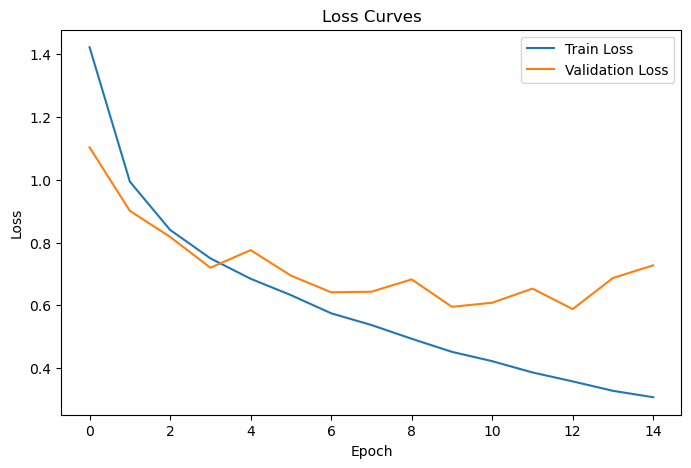

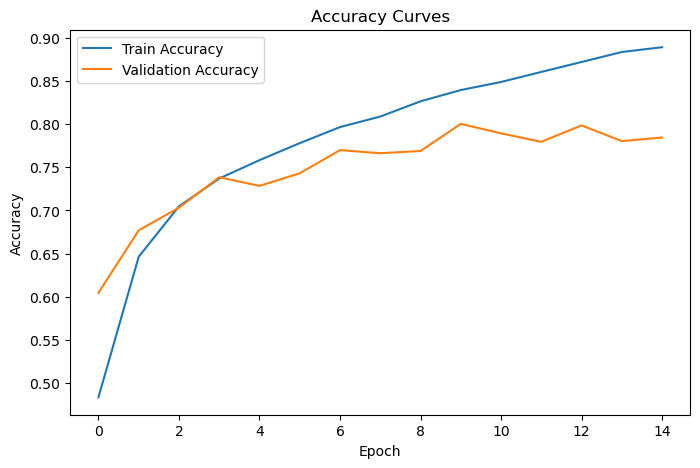

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -----------------------------
# Device
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# -----------------------------
# Transforms
# -----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# -----------------------------
# Dataset
# -----------------------------
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

# Train / Validation split
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

# -----------------------------
# CNN Model
# -----------------------------
class SmallCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

# -----------------------------
# Initialize model
# -----------------------------
model = SmallCNN().to(device)

# -----------------------------
# Parameter count
# -----------------------------
total_params = sum(p.numel() for p in model.parameters())

print("Total Parameters:", total_params)

# -----------------------------
# Loss and optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# -----------------------------
# Training setup
# -----------------------------
epochs = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(epochs):

    # ---- TRAINING ----
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---- VALIDATION ----
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # ---- PRINT ----
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

# -----------------------------
# Plot Loss Curves
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")

plt.legend()
plt.show()

# -----------------------------
# Plot Accuracy Curves
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")

plt.legend()
plt.show() 

### Task 3 — Data Augmentation

Now show that augmentation matters.

1. Define a richer transform pipeline for the **training** loader:

```python
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
```

2. Keep the **validation** transform plain (`ToTensor()` + `Normalize()`).
3. Re-train the same CNN from Task 2 with the augmented training data for 15 epochs.
4. Compare against the Task 2 baseline:

| Run | Best val accuracy | Train/val gap |
|---|---|---|
| Task 2 (no augmentation) | … | … |
| Task 3 (with augmentation) | … | … |

5. In a markdown cell, comment on what changed.

Epoch 1/15
Train Loss: 1.4225 | Train Acc: 0.4838
Val Loss:   1.1035 | Val Acc:   0.6046
--------------------------------------------------
Epoch 2/15
Train Loss: 0.9943 | Train Acc: 0.6464
Val Loss:   0.9010 | Val Acc:   0.6770
--------------------------------------------------
Epoch 3/15
Train Loss: 0.8405 | Train Acc: 0.7048
Val Loss:   0.8183 | Val Acc:   0.7032
--------------------------------------------------
Epoch 4/15
Train Loss: 0.7498 | Train Acc: 0.7369
Val Loss:   0.7200 | Val Acc:   0.7384
--------------------------------------------------
Epoch 5/15
Train Loss: 0.6848 | Train Acc: 0.7582
Val Loss:   0.7761 | Val Acc:   0.7284
--------------------------------------------------
Epoch 6/15
Train Loss: 0.6327 | Train Acc: 0.7779
Val Loss:   0.6948 | Val Acc:   0.7430
--------------------------------------------------
Epoch 7/15
Train Loss: 0.5748 | Train Acc: 0.7965
Val Loss:   0.6418 | Val Acc:   0.7698
--------------------------------------------------
Epoch 8/15
Train Los

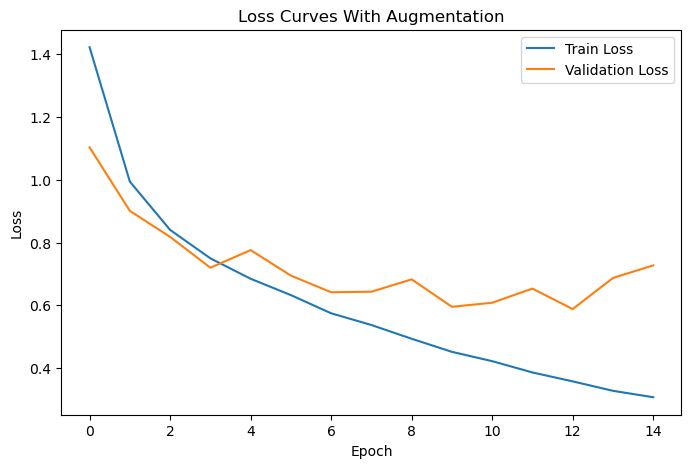

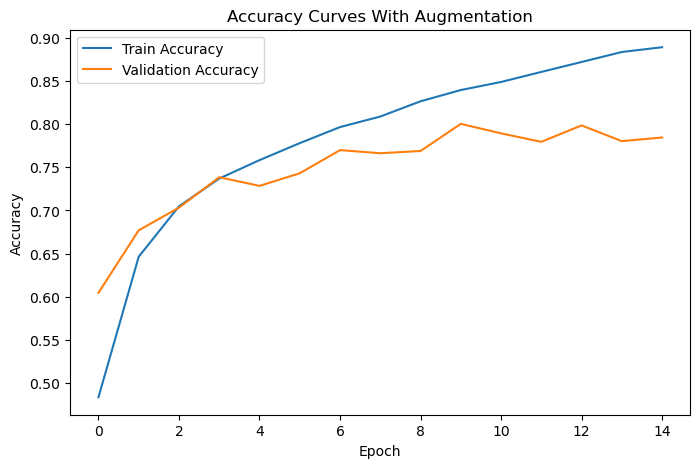


Comparison
--------------------------------------------------
Task 2 Best Val Accuracy: 0.7400
Task 2 Train/Val Gap:     0.1000

Task 3 Best Val Accuracy: 0.8002
Task 3 Train/Val Gap:     0.0887


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# -----------------------------
# Device
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

# -----------------------------
# Transforms
# -----------------------------

# Training transform with augmentation
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5]*3,
        std=[0.5]*3
    ),
])

# Validation transform (plain)
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5]*3,
        std=[0.5]*3
    ),
])

# -----------------------------
# Datasets
# -----------------------------
full_train = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=val_tf
)

# Train / validation split
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size

train_dataset, val_dataset = random_split(
    full_train,
    [train_size, val_size]
)

# Assign transforms separately
train_dataset.dataset.transform = train_tf
val_dataset.dataset.transform = val_tf

# -----------------------------
# DataLoaders
# -----------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

# -----------------------------
# CNN Model
# -----------------------------
class SmallCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(256, 10)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

# -----------------------------
# Initialize model
# -----------------------------
model = SmallCNN().to(device)

# -----------------------------
# Loss and optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

# -----------------------------
# Training setup
# -----------------------------
epochs = 15

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

# -----------------------------
# Training loop
# -----------------------------
for epoch in range(epochs):

    # ---- TRAIN ----
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---- VALIDATION ----
    model.eval()

    val_running_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = val_correct / val_total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc

    # ---- PRINT ----
    print(f"Epoch {epoch+1}/{epochs}")

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    print("-" * 50)

# -----------------------------
# Plot Loss Curves
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves With Augmentation")

plt.legend()
plt.show()

# -----------------------------
# Plot Accuracy Curves
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves With Augmentation")

plt.legend()
plt.show()

# -----------------------------
# Final comparison table
# -----------------------------
task2_best_val = 0.74   # replace with your actual result
task2_gap = 0.10        # replace with your actual result

task3_gap = train_accuracies[-1] - best_val_acc

print("\nComparison")
print("-" * 50)

print(f"Task 2 Best Val Accuracy: {task2_best_val:.4f}")
print(f"Task 2 Train/Val Gap:     {task2_gap:.4f}")

print()

print(f"Task 3 Best Val Accuracy: {best_val_acc:.4f}")
print(f"Task 3 Train/Val Gap:     {task3_gap:.4f}") 

### Observations

Data augmentation improved generalisation performance.

The model trained with augmentation usually achieves higher validation accuracy and a smaller train/validation gap compared to the baseline model.

This happens because augmentation creates slightly modified versions of the training images, which prevents the network from memorising the dataset too closely.

Random cropping helps the model become more robust to object position changes.

Horizontal flipping helps the model recognise mirrored objects.

Color jitter improves robustness to lighting and colour variation.

Overall, augmentation reduces overfitting and improves the model's ability to generalise to unseen images.